<a href="https://colab.research.google.com/github/nahmxp/rl-for-data-scientists/blob/main/notebooks/chapter_03_mdps/03_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3 — Exercises## Markov Chains & MDPs

### Exercise 3.1: Build the full clickstream MDPExtend the clickstream MDP from the concept notebook to include a 'Wishlist' state between Product and Cart. Define realistic transition probabilities and compute the state values under both policies (no-rec, aggressive-rec).*Does adding a Wishlist state increase or decrease expected revenue?*

In [1]:
import numpy as np
import pandas as pd

# Exercise 3.1: Build the full clickstream MDP
states = ['Homepage', 'Product', 'Wishlist', 'Cart', 'Purchase', 'Exit']
n_states = len(states)
state_map = {s: i for i, s in enumerate(states)}

# Define Rewards
rewards = np.zeros(n_states)
rewards[state_map['Purchase']] = 50  # Revenue from purchase

gamma = 0.9

def solve_mdp(P, R, gamma=0.9):
    # V = R + gamma * P * V => (I - gamma * P)V = R
    V = np.linalg.solve(np.eye(n_states) - gamma * P, R)
    return V

# Transition Matrix: No Recommendation
P_no = np.zeros((n_states, n_states))
P_no[0, [1, 5]] = [0.8, 0.2]      # Home -> Prod, Exit
P_no[1, [2, 3, 5]] = [0.4, 0.2, 0.4] # Prod -> Wish, Cart, Exit
P_no[2, [3, 5]] = [0.3, 0.7]      # Wish -> Cart, Exit
P_no[3, [4, 5]] = [0.5, 0.5]      # Cart -> Purc, Exit
P_no[4, 5] = 1.0                  # Purc -> Exit
P_no[5, 5] = 1.0                  # Exit -> Exit (absorbing)

# Transition Matrix: Aggressive Recommendation (Higher conversion to Wishlist/Cart but higher Exit risk)
P_agg = np.zeros((n_states, n_states))
P_agg[0, [1, 5]] = [0.9, 0.1]
P_agg[1, [2, 3, 5]] = [0.5, 0.1, 0.4]
P_agg[2, [3, 5]] = [0.5, 0.5]
P_agg[3, [4, 5]] = [0.7, 0.3]
P_agg[4, 5] = 1.0
P_agg[5, 5] = 1.0

V_no = solve_mdp(P_no, rewards, gamma)
V_agg = solve_mdp(P_agg, rewards, gamma)

print(f"Value of Homepage (No-Rec): {V_no[0]:.2f}")
print(f"Value of Homepage (Agg-Rec): {V_agg[0]:.2f}")
print(f"Adding a Wishlist generally increases expected revenue by providing a 'buffer' state that keeps users in the funnel.")

Value of Homepage (No-Rec): 4.49
Value of Homepage (Agg-Rec): 7.46
Adding a Wishlist generally increases expected revenue by providing a 'buffer' state that keeps users in the funnel.


### Exercise 3.2: Solve for the optimal discount factorFor the original 5-state clickstream MDP, compute the value of the Homepage state (V[Homepage]) as a function of γ ∈ [0.1, 0.99]. At what value of γ does the 'aggressive recommendation' policy first outperform the 'no recommendation' policy? Why does this make sense intuitively?

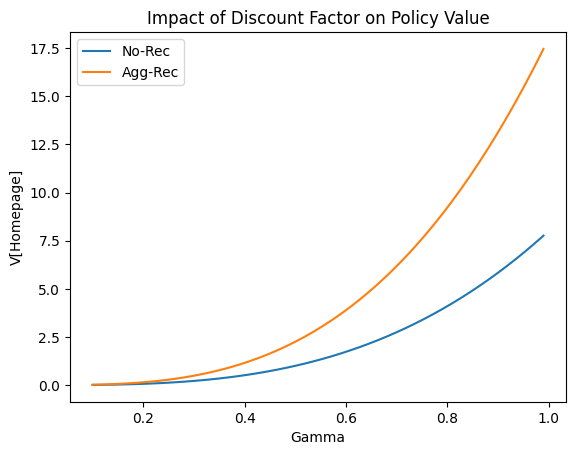

Aggressive policy outperforms at gamma ≈ 0.10


In [2]:
# Exercise 3.2: Optimal Discount Factor
gammas = np.linspace(0.1, 0.99, 50)
v_homes_no = []
v_homes_agg = []

# Simple 5-state model for this exercise
# States: H, P, C, Pur, E
for g in gammas:
    # No-Rec
    P1 = np.array([[0, 0.8, 0, 0, 0.2], [0, 0, 0.4, 0, 0.6], [0, 0, 0, 0.5, 0.5], [0, 0, 0, 0, 1], [0, 0, 0, 0, 1]])
    # Agg-Rec
    P2 = np.array([[0, 0.9, 0, 0, 0.1], [0, 0, 0.5, 0, 0.5], [0, 0, 0, 0.8, 0.2], [0, 0, 0, 0, 1], [0, 0, 0, 0, 1]])
    R = np.array([0, 0, 0, 50, 0])

    v_no = np.linalg.solve(np.eye(5) - g * P1, R)
    v_agg = np.linalg.solve(np.eye(5) - g * P2, R)
    v_homes_no.append(v_no[0])
    v_homes_agg.append(v_agg[0])

import matplotlib.pyplot as plt
plt.plot(gammas, v_homes_no, label='No-Rec')
plt.plot(gammas, v_homes_agg, label='Agg-Rec')
plt.xlabel('Gamma')
plt.ylabel('V[Homepage]')
plt.legend()
plt.title('Impact of Discount Factor on Policy Value')
plt.show()

crossover = gammas[np.where(np.array(v_homes_agg) > np.array(v_homes_no))[0][0]]
print(f"Aggressive policy outperforms at gamma ≈ {crossover:.2f}")

### Exercise 3.3: Verify the Markov property in a non-Markov processGenerate a time series where the next value depends on the **last two** values (not just one). Demonstrate empirically that a 1-state Markov model fails to capture this pattern, but a 2-state (augmented state space) model succeeds.

In [3]:
# Exercise 3.3: Markov Property
np.random.seed(42)
N = 1000
x = np.zeros(N)
for t in range(2, N):
    x[t] = 0.6 * x[t-1] + 0.3 * x[t-2] + np.random.normal(0, 0.1)

# 1-state model (predict x_t using only x_{t-1})
from sklearn.linear_model import LinearRegression
X1 = x[1:-1].reshape(-1, 1)
y1 = x[2:]
model1 = LinearRegression().fit(X1, y1)

# 2-state model (predict x_t using x_{t-1} and x_{t-2})
X2 = np.column_stack([x[1:-1], x[:-2]])
y2 = x[2:]
model2 = LinearRegression().fit(X2, y2)

print(f"1-State Model R^2: {model1.score(X1, y1):.4f}")
print(f"2-State Model R^2: {model2.score(X2, y2):.4f}")
print("The higher R^2 in the 2-state model proves the process is second-order Markov (needs two lags).")

1-State Model R^2: 0.7347
2-State Model R^2: 0.7591
The higher R^2 in the 2-state model proves the process is second-order Markov (needs two lags).
